# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026

# EDA 1. nuSQuIDS Interface Exploration
---

This notebook explores the external `nuSQuIDS` Python bindings used as an independent oscillation reference. It is based on the original `nusquids_test.py` helper and keeps the workflow notebook-friendly: inspect availability, configure the solver, run controlled vacuum and Earth-atmosphere examples, and visualize probability grids.

## 1. Libraries

This section imports the numerical stack, plotting tools, lightweight dataclasses, and dynamic import utilities needed to keep `nuSQuIDS` optional.

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
import importlib
from typing import Iterable, Optional, Sequence
import warnings

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tpeanuts.notebooks.notebookConfig import load_notebook_config

## 2. Paths and Configuration

The notebook searches upward from the current working directory until it finds the TPeanuts project root. Generated tables and figures are written under the external output branch.

### 2.1. Paths

The path block mirrors the rest of the TPeanuts notebooks: a configurable output root, explicit data/analysis/benchmark/test branches, and a notebook-specific output directory.

In [2]:
config = load_notebook_config()

PROJECT_DIR = config.package_dir
PACKAGE_DIR = PROJECT_DIR

OUTPUT_DIR = config.output_dir("analysis", "external", "nusquids", "eda")

print(f"Project directory: {PROJECT_DIR}")
print(f"Output directory : {OUTPUT_DIR}")

Project directory: /mnt/g/Mi unidad/03.Codigo/034.TFM.UV/Tpeanuts
Output directory : /mnt/v/output/analysis/external/nusquids/eda


### 2.2. Configuration Parameters

These parameters define the oscillation model, solver tolerances, grids, plotting choices, and flavour labels. Angles are in radians, mass splittings are in eVÂ², energies are in GeV, and baselines are in km.

In [3]:
FLAVOUR_NAMES = ("nue", "numu", "nutau")
FLAVOUR_INDEX = {
    "nue": 0,
    "nu_e": 0,
    "e": 0,
    "numu": 1,
    "nu_mu": 1,
    "mu": 1,
    "nutau": 2,
    "nu_tau": 2,
    "tau": 2,
}


@dataclass(frozen=True)
class OscillationParameters:
    theta12: float = 0.59
    theta13: float = 0.15
    theta23: float = 0.78
    delta_cp: float = 1.20
    DeltamSq21: float = 7.42e-5
    DeltamSq3l: float = 2.517e-3


@dataclass(frozen=True)
class NuSQuIDSConfig:
    rel_error: float = 1.0e-10
    abs_error: float = 1.0e-12
    h_max_km: Optional[float] = 500.0
    set_default_mixing_first: bool = False
    set_cp_phase: bool = True
    strict_cp: bool = False


PARAMS = OscillationParameters()
NSQ_CONFIG = NuSQuIDSConfig()

ENERGIES_GEV = np.array([0.5, 1.0, 3.0, 10.0, 30.0, 100.0], dtype=float)
BASELINES_KM = np.array([20.0, 100.0, 500.0, 1000.0, 5000.0, 10000.0], dtype=float)
INITIAL_FLAVOURS = ("nue", "numu", "nutau")

PLOT_BASELINE_KM = 1000.0
PLOT_INITIAL_FLAVOUR = "numu"
PLOT_ENERGIES_GEV = np.logspace(-1, 3, 80)
PLOT_COS_ZENITH = np.linspace(-1.0, 1.0, 41)

print("Oscillation parameters")
display(pd.DataFrame([asdict(PARAMS)]))
print("nuSQuIDS numerical configuration")
display(pd.DataFrame([asdict(NSQ_CONFIG)]))

Oscillation parameters


,theta12,theta13,theta23,delta_cp,DeltamSq21,DeltamSq3l
0,0.59,0.15,0.78,1.2,0.000074,0.002517


nuSQuIDS numerical configuration


,rel_error,abs_error,h_max_km,set_default_mixing_first,set_cp_phase,strict_cp
0,1.000000e-10,1.000000e-12,500.0,False,True,False


## 3. Optional Backend Discovery

`nuSQuIDS` is optional. The notebook tries the common module names used by wheel and source builds, then reports a clear installation message if none are importable.

In [4]:
class NuSQuIDSError(RuntimeError):
    """Raised when nuSQuIDS is unavailable or cannot run a requested setup."""


def require_nusquids():
    errors = []
    for module_name in ("nuSQuIDS", "nuSQUIDSpy", "nusquids"):
        try:
            return importlib.import_module(module_name)
        except Exception as exc:
            errors.append(f"{module_name}: {type(exc).__name__}: {exc}")

    message = (
        "nuSQuIDS Python bindings are not installed or not importable.\n"
        "Install them in the active environment, for example:\n\n"
        "    pip install nusquids\n\n"
        "If using a source build, add the bindings directory to PYTHONPATH.\n"
        "Import attempts:\n  - "
        + "\n  - ".join(errors)
    )
    raise NuSQuIDSError(message)


def is_available() -> bool:
    try:
        require_nusquids()
    except NuSQuIDSError:
        return False
    return True


try:
    nsq_module = require_nusquids()
    print("nuSQuIDS module:", nsq_module.__name__)
    print("nuSQuIDS available:", True)
except NuSQuIDSError as exc:
    nsq_module = None
    print(exc)

nuSQuIDS module: nuSQuIDS
nuSQuIDS available: True


## 4. nuSQuIDS Helper Layer

The original script keeps the public surface narrow: configure a solver, build an initial flavour state, evaluate final probabilities, and expose vacuum/Earth-atmosphere calls with stable table output.

In [5]:
def _units(nsq):
    if hasattr(nsq, "Const"):
        return nsq.Const()

    class FallbackUnits:
        GeV = 1.0e9
        km = 5.067730716e18

    warnings.warn(
        "nuSQuIDS module has no Const() helper; using fallback natural-unit conversion constants.",
        RuntimeWarning,
        stacklevel=2,
    )
    return FallbackUnits()


def _flavour_index(flavour: str | int) -> int:
    if isinstance(flavour, int):
        if flavour not in (0, 1, 2):
            raise ValueError("Integer flavour index must be 0, 1 or 2.")
        return flavour

    key = str(flavour).lower().replace("anti", "").replace("bar", "").strip("_")
    if key not in FLAVOUR_INDEX:
        raise ValueError(f"Unknown flavour {flavour!r}. Use one of {sorted(FLAVOUR_INDEX)}.")
    return FLAVOUR_INDEX[key]


def _neutrino_type(nsq, *, antinu: bool):
    return nsq.NeutrinoType.antineutrino if antinu else nsq.NeutrinoType.neutrino


def _initial_state(flavour: str | int, n_flavours: int = 3) -> np.ndarray:
    state = np.zeros(n_flavours, dtype=float)
    state[_flavour_index(flavour)] = 1.0
    return state


def _set_cp_phase(nuSQ, params: OscillationParameters, config: NuSQuIDSConfig) -> None:
    if not config.set_cp_phase:
        return

    candidates = (
        ("Set_CPPhase", (0, 2, params.delta_cp)),
        ("Set_CPPhase", (1, 3, params.delta_cp)),
        ("Set_CPPhase", (params.delta_cp,)),
        ("Set_DeltaCP", (params.delta_cp,)),
        ("Set_CP_Phase", (params.delta_cp,)),
    )

    for method_name, args in candidates:
        method = getattr(nuSQ, method_name, None)
        if method is None:
            continue
        try:
            method(*args)
            return
        except TypeError:
            continue

    message = "Could not set delta_cp on this nuSQuIDS Python object. The calculation may use backend defaults."
    if config.strict_cp:
        raise NuSQuIDSError(message)
    warnings.warn(message, RuntimeWarning, stacklevel=2)


def configure_solver(
    nuSQ,
    params: OscillationParameters = PARAMS,
    config: NuSQuIDSConfig = NSQ_CONFIG,
) -> None:
    if config.set_default_mixing_first and hasattr(nuSQ, "Set_MixingParametersToDefault"):
        nuSQ.Set_MixingParametersToDefault()

    nuSQ.Set_MixingAngle(0, 1, params.theta12)
    nuSQ.Set_MixingAngle(0, 2, params.theta13)
    nuSQ.Set_MixingAngle(1, 2, params.theta23)
    nuSQ.Set_SquareMassDifference(1, params.DeltamSq21)
    nuSQ.Set_SquareMassDifference(2, params.DeltamSq3l)
    _set_cp_phase(nuSQ, params, config)

    if hasattr(nuSQ, "Set_rel_error"):
        nuSQ.Set_rel_error(float(config.rel_error))
    if hasattr(nuSQ, "Set_abs_error"):
        nuSQ.Set_abs_error(float(config.abs_error))
    if config.h_max_km is not None and hasattr(nuSQ, "Set_h_max"):
        units = _units(require_nusquids())
        nuSQ.Set_h_max(float(config.h_max_km) * units.km)


def _make_single_energy_solver(*, antinu: bool, params: OscillationParameters, config: NuSQuIDSConfig):
    nsq = require_nusquids()
    nuSQ = nsq.nuSQUIDS(3, _neutrino_type(nsq, antinu=antinu))
    configure_solver(nuSQ, params=params, config=config)
    return nsq, nuSQ


def _eval_probabilities(nuSQ, *, output_energy_GeV: Optional[float] = None, antinu_index: int = 0) -> np.ndarray:
    nsq = require_nusquids()
    units = _units(nsq)
    values = []
    for flavour in range(3):
        if output_energy_GeV is None:
            values.append(float(nuSQ.EvalFlavor(flavour)))
            continue
        try:
            values.append(float(nuSQ.EvalFlavor(flavour, float(output_energy_GeV) * units.GeV, antinu_index)))
        except TypeError:
            values.append(float(nuSQ.EvalFlavor(flavour, float(output_energy_GeV) * units.GeV)))
    return np.asarray(values, dtype=float)

## 5. Vacuum Propagation API

The vacuum mode is the cleanest reference case because it avoids density-model and geometry-convention ambiguities. Each call returns probabilities ordered as `nue`, `numu`, and `nutau`.

In [6]:
def vacuum_probability(
    *,
    E_GeV: float,
    baseline_km: float,
    initial_flavour: str | int = "numu",
    antinu: bool = False,
    params: OscillationParameters = PARAMS,
    config: NuSQuIDSConfig = NSQ_CONFIG,
) -> dict[str, object]:
    nsq, nuSQ = _make_single_energy_solver(antinu=antinu, params=params, config=config)
    units = _units(nsq)

    nuSQ.Set_Body(nsq.Vacuum())
    nuSQ.Set_Track(nsq.Vacuum.Track(float(baseline_km) * units.km))
    nuSQ.Set_E(float(E_GeV) * units.GeV)
    nuSQ.Set_initial_state(_initial_state(initial_flavour), nsq.Basis.flavor)
    nuSQ.EvolveState()

    return {
        "backend": "nuSQuIDS",
        "mode": "vacuum",
        "E_GeV": float(E_GeV),
        "baseline_km": float(baseline_km),
        "initial_flavour": initial_flavour,
        "antinu": bool(antinu),
        "params": asdict(params),
        "config": asdict(config),
        "flavours": FLAVOUR_NAMES,
        "probabilities": _eval_probabilities(nuSQ),
    }


def probability_grid_vacuum(
    *,
    E_GeV: Sequence[float],
    baseline_km: Sequence[float],
    initial_flavours: Iterable[str | int] = INITIAL_FLAVOURS,
    antinu: bool = False,
    params: OscillationParameters = PARAMS,
    config: NuSQuIDSConfig = NSQ_CONFIG,
) -> pd.DataFrame:
    rows = []
    for beta in initial_flavours:
        for energy in E_GeV:
            for baseline in baseline_km:
                result = vacuum_probability(
                    E_GeV=float(energy),
                    baseline_km=float(baseline),
                    initial_flavour=beta,
                    antinu=antinu,
                    params=params,
                    config=config,
                )
                probs = result["probabilities"]
                rows.append(
                    {
                        "backend": "nuSQuIDS",
                        "mode": "vacuum",
                        "E_GeV": float(energy),
                        "baseline_km": float(baseline),
                        "initial_flavour": str(beta),
                        "antinu": bool(antinu),
                        "P_nue": probs[0],
                        "P_numu": probs[1],
                        "P_nutau": probs[2],
                    }
                )
    return pd.DataFrame.from_records(rows)


if is_available():
    example = vacuum_probability(E_GeV=3.0, baseline_km=1000.0, initial_flavour="numu")
    display(pd.DataFrame([dict(zip(example["flavours"], example["probabilities"]))]))
else:
    print("Skipping vacuum example because nuSQuIDS is unavailable.")

,nue,numu,nutau
0,0.028454,0.254239,0.717307


## 6. Vacuum Probability Grid

This block runs the compact grid used for external validation and checks that final-state probabilities remain normalized.

In [7]:
if is_available():
    vacuum_table = probability_grid_vacuum(
        E_GeV=ENERGIES_GEV,
        baseline_km=BASELINES_KM,
        initial_flavours=INITIAL_FLAVOURS,
        antinu=False,
    )
    vacuum_table["probability_sum"] = vacuum_table[["P_nue", "P_numu", "P_nutau"]].sum(axis=1)
    vacuum_table["normalization_error"] = np.abs(vacuum_table["probability_sum"] - 1.0)
    display(vacuum_table.head(12))
    display(vacuum_table.groupby("initial_flavour")["normalization_error"].agg(["max", "median"]))
else:
    vacuum_table = pd.DataFrame()
    print("Skipping vacuum grid because nuSQuIDS is unavailable.")

,backend,mode,E_GeV,baseline_km,initial_flavour,antinu,P_nue,P_numu,P_nutau,probability_sum,normalization_error
0,nuSQuIDS,vacuum,0.5,20.0,nue,False,0.998601,0.000753,0.000646,1.0,2.220446e-16
1,nuSQuIDS,vacuum,0.5,100.0,nue,False,0.969234,0.017737,0.013029,1.0,2.220446e-16
2,nuSQuIDS,vacuum,0.5,500.0,nue,False,0.992606,0.003851,0.003543,1.0,0.000000e+00
3,nuSQuIDS,vacuum,0.5,1000.0,nue,False,0.970681,0.015063,0.014256,1.0,2.220446e-16
4,nuSQuIDS,vacuum,0.5,5000.0,nue,False,0.449064,0.249044,0.301892,1.0,0.000000e+00
5,nuSQuIDS,vacuum,0.5,10000.0,nue,False,0.201455,0.264154,0.534391,1.0,1.110223e-16
6,nuSQuIDS,vacuum,1.0,20.0,nue,False,0.999649,0.000187,0.000164,1.0,1.110223e-16
7,nuSQuIDS,vacuum,1.0,100.0,nue,False,0.991493,0.004706,0.003800,1.0,0.000000e+00
8,nuSQuIDS,vacuum,1.0,500.0,nue,False,0.910912,0.055948,0.033140,1.0,0.000000e+00
9,nuSQuIDS,vacuum,1.0,1000.0,nue,False,0.992606,0.003851,0.003543,1.0,0.000000e+00


,max,median
initial_flavour,,
nue,2.220446e-16,0.000000e+00
numu,2.220446e-16,5.551115e-17
nutau,2.220446e-16,1.110223e-16


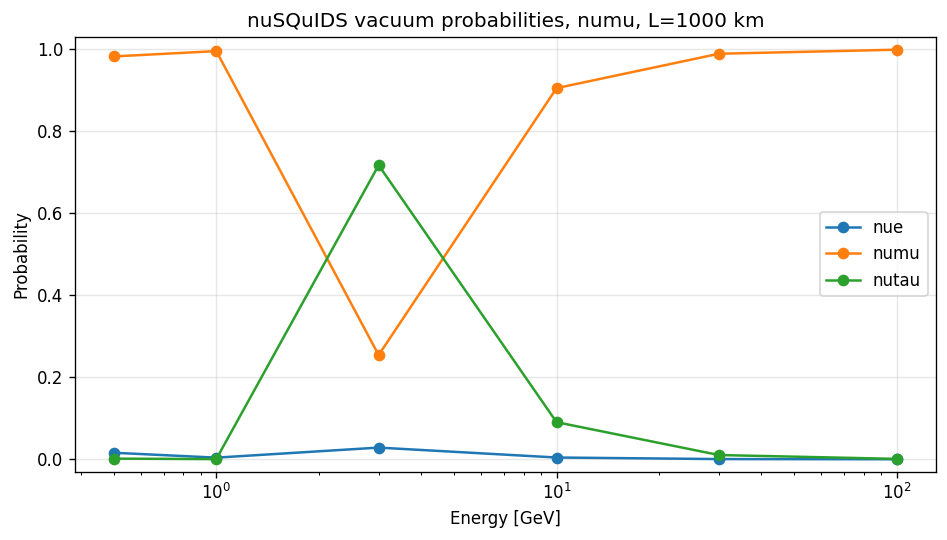

In [8]:
if not vacuum_table.empty:
    plot_df = vacuum_table[
        (vacuum_table["baseline_km"] == PLOT_BASELINE_KM)
        & (vacuum_table["initial_flavour"] == PLOT_INITIAL_FLAVOUR)
    ].sort_values("E_GeV")

    fig, ax = plt.subplots(figsize=(8.0, 4.6))
    for flavour in FLAVOUR_NAMES:
        ax.semilogx(plot_df["E_GeV"], plot_df[f"P_{flavour}"], marker="o", label=flavour)
    ax.set_xlabel("Energy [GeV]")
    ax.set_ylabel("Probability")
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(f"nuSQuIDS vacuum probabilities, {PLOT_INITIAL_FLAVOUR}, L={PLOT_BASELINE_KM:g} km")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "nusquids_vacuum_grid_slice.png", dpi=180, bbox_inches="tight")
    plt.show()

## 7. Earth-Atmosphere Mode

The atmospheric mode uses `EarthAtm.MakeTrackWithCosine(cos_zenith)`. The notebook keeps this convention explicit because detector-facing angle conventions often differ between packages.

In [9]:
def earth_atm_probability(
    *,
    E_GeV: float,
    cos_zenith: float,
    initial_flavour: str | int = "numu",
    antinu: bool = False,
    params: OscillationParameters = PARAMS,
    config: NuSQuIDSConfig = NSQ_CONFIG,
) -> dict[str, object]:
    nsq, nuSQ = _make_single_energy_solver(antinu=antinu, params=params, config=config)
    units = _units(nsq)

    cos_zenith = float(cos_zenith)
    if cos_zenith < -1.0 or cos_zenith > 1.0:
        raise ValueError("cos_zenith must be in [-1, 1].")

    earth = nsq.EarthAtm()
    nuSQ.Set_Body(earth)
    nuSQ.Set_Track(earth.MakeTrackWithCosine(cos_zenith))
    nuSQ.Set_E(float(E_GeV) * units.GeV)
    nuSQ.Set_initial_state(_initial_state(initial_flavour), nsq.Basis.flavor)
    nuSQ.EvolveState()

    return {
        "backend": "nuSQuIDS",
        "mode": "earth_atm",
        "E_GeV": float(E_GeV),
        "cos_zenith": cos_zenith,
        "initial_flavour": initial_flavour,
        "antinu": bool(antinu),
        "params": asdict(params),
        "config": asdict(config),
        "flavours": FLAVOUR_NAMES,
        "probabilities": _eval_probabilities(nuSQ),
    }


if is_available():
    rows = []
    for cz in PLOT_COS_ZENITH:
        result = earth_atm_probability(E_GeV=10.0, cos_zenith=float(cz), initial_flavour="numu")
        probs = result["probabilities"]
        rows.append({"cos_zenith": float(cz), "P_nue": probs[0], "P_numu": probs[1], "P_nutau": probs[2]})
    earth_table = pd.DataFrame(rows)
    display(earth_table.head())
else:
    earth_table = pd.DataFrame()
    print("Skipping EarthAtm scan because nuSQuIDS is unavailable.")

,cos_zenith,P_nue,P_numu,P_nutau
0,-1.00,0.065831,0.509361,0.424808
1,-0.95,0.009677,0.767491,0.222833
2,-0.90,0.137359,0.779626,0.083015
3,-0.85,0.028321,0.951258,0.020422
4,-0.80,0.072089,0.904989,0.022922


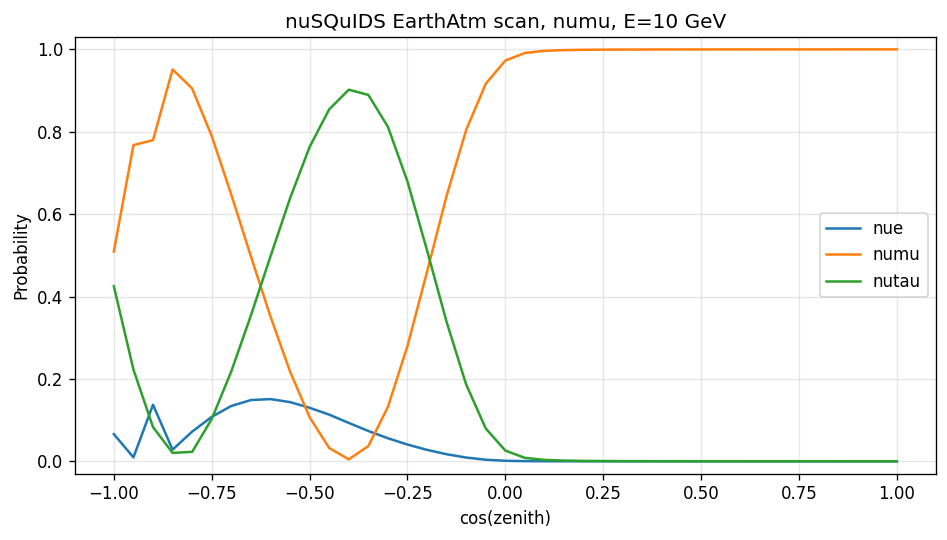

In [10]:
if not earth_table.empty:
    fig, ax = plt.subplots(figsize=(8.0, 4.6))
    for flavour in FLAVOUR_NAMES:
        ax.plot(earth_table["cos_zenith"], earth_table[f"P_{flavour}"], label=flavour)
    ax.set_xlabel("cos(zenith)")
    ax.set_ylabel("Probability")
    ax.set_ylim(-0.03, 1.03)
    ax.set_title("nuSQuIDS EarthAtm scan, numu, E=10 GeV")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "nusquids_earthatm_coszenith_scan.png", dpi=180, bbox_inches="tight")
    plt.show()

## 8. Exported Reference Tables

The exported CSV files provide reusable external references for later TPeanuts validation notebooks or tests.

In [11]:
saved_paths = []

if not vacuum_table.empty:
    path = OUTPUT_DIR / "nusquids_vacuum_grid.csv"
    vacuum_table.to_csv(path, index=False)
    saved_paths.append(path)

if not earth_table.empty:
    path = OUTPUT_DIR / "nusquids_earthatm_coszenith_scan.csv"
    earth_table.to_csv(path, index=False)
    saved_paths.append(path)

for path in saved_paths:
    print(path)

/mnt/v/output/analysis/external/nusquids/eda/nusquids_vacuum_grid.csv
/mnt/v/output/analysis/external/nusquids/eda/nusquids_earthatm_coszenith_scan.csv
